With this code one may create a neural network and train it to predict the nuclearity of the model thorium-oxide clusters from the calculated PDF data.

In [7]:
import numpy as np
np.random.seed(1337) 
import pandas as pd
import glob
import os
import itertools

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import Normalizer
from sklearn.metrics import confusion_matrix, recall_score, f1_score, precision_score

import keras
import keras.regularizers
from keras.models import Sequential
from keras.layers import Dense, Conv1D, BatchNormalization, MaxPooling1D, Flatten, Dropout
from keras_self_attention import SeqSelfAttention
from keras.utils import custom_object_scope
from keras.callbacks import ModelCheckpoint, EarlyStopping
from keras.optimizers import Adam
from keras_tuner import Hyperband

In [8]:
os.chdir('/Users/dimitrygrebenyuk/Yandex.Disk.localized/Working/PDF/Refinements/PDF-Cluster-Prediction/th_clusters/test_th_groups')

In [9]:
files_calc = glob.glob('*.dat')

Let's slice a structure set for it to be shorter and more balanced in terms of heavy atom counts

Counts of clusters by their nuclearity: {'1': 2535, '2': 2765, '3': 2069, '4': 1297, '5': 704, '6': 377, '7': 160, '8': 66, '9': 25}
Sliced cluster catalogue: ['1_5693.dat', '4_5316.dat', '2_7982.dat', '2_9777.dat', '2_2622.dat', '4_6179.dat', '2_2144.dat', '3_6450.dat', '4_3001.dat', '1_3584.dat', '3_4247.dat', '1_3590.dat', '3_4253.dat', '4_5464.dat', '5_434.dat', '2_4521.dat', '3_6444.dat', '5_3029.dat', '3_7014.dat', '2_845.dat', '3_5603.dat', '4_4034.dat', '6_4926.dat', '3_5165.dat', '2_1471.dat', '2_4509.dat', '1_7912.dat', '3_9993.dat', '3_7766.dat', '3_1317.dat', '3_3266.dat', '2_9987.dat', '3_2178.dat', '1_5863.dat', '2_3514.dat', '6_6843.dat', '1_6359.dat', '2_4290.dat', '3_471.dat', '2_7941.dat', '3_2193.dat', '2_6487.dat', '6_2416.dat', '3_4284.dat', '1_3547.dat', '2_2187.dat', '1_1350.dat', '2_3299.dat', '1_8406.dat', '3_303.dat', '1_7735.dat', '2_110.dat', '2_5824.dat', '1_2895.dat', '8_8278.dat', '2_9978.dat', '4_182.dat', '1_4572.dat', '4_2486.dat', '2_9950.dat', '1_636

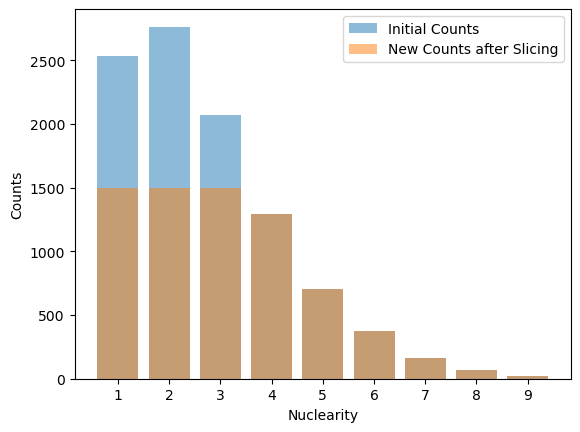

In [10]:
from collections import defaultdict
import matplotlib.pyplot as plt

def analyze_filenames(filenames):
    # Count how many filenames start with each digit from 1 to 9
    counts = defaultdict(int)
    for filename in filenames:
        if filename[0].isdigit() and filename[0] != '0':
            counts[filename[0]] += 1
            
    return counts

def create_output_array(filenames, selected_counts):
    # Create the output array based on the selected counts for each digit
    output_array = []
    current_counts = defaultdict(int)
    for filename in filenames:
        digit = filename[0]
        if digit in selected_counts and current_counts[digit] < selected_counts[digit]:
            output_array.append(filename)
            current_counts[digit] += 1
            
    return output_array

counts = analyze_filenames(files_calc)
sorted_counts = {str(digit): counts.get(str(digit), 0) for digit in range(1, 10)}
print("Counts of clusters by their nuclearity:", sorted_counts)

selected_counts = {
    '1': 1500, # Specify how many filenames starting with '1' you want
    '2': 1500, # Specify how many filenames starting with '2' you want
    '3': 1500,  # Specify how many filenames starting with '3' you want
    '4': 1500,  # Specify how many filenames starting with '3' you want
    '5': 1500,  # Specify how many filenames starting with '3' you want
    '6': 1500,  # Specify how many filenames starting with '3' you want
    '7': 1500,  # Specify how many filenames starting with '3' you want
    '8': 1500,  # Specify how many filenames starting with '3' you want
    '9': 1500  # Specify how many filenames starting with '3' you want
}

files_calc_sliced = create_output_array(files_calc, selected_counts)
print("Sliced cluster catalogue:", files_calc_sliced)

counts = analyze_filenames(files_calc_sliced)
sorted_counts2 = {str(digit): counts.get(str(digit), 0) for digit in range(1, 10)}
print("Counts of clusters by their nuclearity:", sorted_counts2)

digits = list(sorted_counts.keys())
initial_values = list(sorted_counts.values())
new_values = list(sorted_counts2.values()) # Use sorted counts for the new values

total_elements_in_sliced = len(files_calc_sliced)
print("Total number of elements in the sliced cluster catalogue:", total_elements_in_sliced)



plt.bar(digits, initial_values, alpha=0.5, label='Initial Counts')
plt.bar(digits, new_values, alpha=0.5, label='New Counts after Slicing')
plt.xlabel('Nuclearity')
plt.ylabel('Counts')
plt.legend()
plt.show()


In [11]:
raw_data_points = []

with open('labels.txt', 'w') as labels:
    for f in files_calc_sliced:
        df = pd.read_csv(f, usecols=[1], skiprows=201, header=None, delim_whitespace=True, skipfooter=800, engine='python')
        raw_data_points.append(df.values.ravel())
        labels.write(f[0])
        labels.write('\n')
    # for f in files_exp:
        # df = pd.read_csv(f, usecols=[1], skiprows=1, header=None, delim_whitespace=True, skipfooter=1, engine='python')
        # raw_data_points.append(df.values.ravel())
        # labels.write(f[0])
        # labels.write('\n')
        
raw_data_points = np.array(raw_data_points)

# Load the labels
labels = pd.read_csv("labels.txt", header=None)
labels = labels.values.ravel()  # convert the labels to a 1D array

3


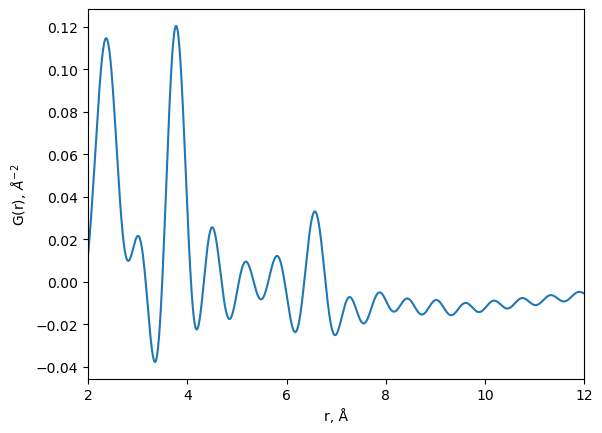

In [12]:
%matplotlib inline
import matplotlib.pyplot as plt
normalize = Normalizer()
data_points = normalize.fit_transform(raw_data_points)
#fig, ax = plt.subplots()
plt.xlim(2,12)
plt.plot(np.arange(len(data_points[114,:]))/100+2, data_points[114,:])
plt.xlabel('r, Å')
plt.ylabel('G(r), $Å^{-2}$')
print(labels[114])

In [13]:
# Split the data into training, validation and test sets
X_train, X_temp, y_train, y_temp = train_test_split(data_points, labels, test_size=0.2, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [ ]:
# Let's do some hyperparameter tuning

def build_model(hp):
    model = Sequential()
    model.add(Conv1D(filters=hp.Choice('filters1', [8, 16, 32]),
                     kernel_size=hp.Choice('kernel_size1', [64, 128, 256]),
                     activation='relu', input_shape=(1000, 1)))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(hp.Float('dropout', 0.2, 0.6, step=0.1)))
    model.add(Conv1D(filters=hp.Choice('filters2', [32, 64, 128]),
                     kernel_size=hp.Choice('kernel_size2', [16, 32, 64]),
                     activation='relu'))
    model.add(Dropout(hp.Float('dropout', 0.2, 0.6, step=0.1)))
    model.add(SeqSelfAttention(attention_width=16, attention_type=SeqSelfAttention.ATTENTION_TYPE_MUL))
    model.add(Flatten())
    model.add(Dense(units=hp.Choice('dense_units', [64, 128, 256]), activation='relu', kernel_regularizer=keras.regularizers.l2(0.01)))
    model.add(Dropout(hp.Float('dropout', 0.2, 0.6, step=0.1)))
    model.add(Dense(units=10, activation='softmax', kernel_regularizer=keras.regularizers.l2(0.01)))
    optimizer = Adam(learning_rate=hp.Float('learning_rate', 1e-4, 1e-1, sampling='log'))
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


In [ ]:
tuner = Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=30,
    factor=3,
    project_name='hyperband_2-12'
)

tuner.search(X_train, y_train, epochs=50, validation_data=(X_val, y_val), callbacks=[EarlyStopping(monitor='val_loss', patience=3)])

Trial 90 Complete [00h 02m 46s]
val_accuracy: 0.7587657570838928

Best val_accuracy So Far: 0.9761570692062378
Total elapsed time: 02h 11m 05s
INFO:tensorflow:Oracle triggered exit


In [ ]:
tuner.search_space_summary()
best_hyperparameters = tuner.get_best_hyperparameters(num_trials=1)[0]
print(best_hyperparameters.values)
best_model = tuner.get_best_models(num_models=1)[0]
best_model.save('tuned_sliced_th_calc_2-12.h5')

Search space summary
Default search space size: 7
filters1 (Choice)
{'default': 8, 'conditions': [], 'values': [8, 16, 32], 'ordered': True}
kernel_size1 (Choice)
{'default': 64, 'conditions': [], 'values': [64, 128, 256], 'ordered': True}
dropout (Float)
{'default': 0.2, 'conditions': [], 'min_value': 0.2, 'max_value': 0.6, 'step': 0.1, 'sampling': 'linear'}
filters2 (Choice)
{'default': 32, 'conditions': [], 'values': [32, 64, 128], 'ordered': True}
kernel_size2 (Choice)
{'default': 16, 'conditions': [], 'values': [16, 32, 64], 'ordered': True}
dense_units (Choice)
{'default': 64, 'conditions': [], 'values': [64, 128, 256], 'ordered': True}
learning_rate (Float)
{'default': 0.0001, 'conditions': [], 'min_value': 0.0001, 'max_value': 0.1, 'step': None, 'sampling': 'log'}
{'filters1': 32, 'kernel_size1': 128, 'dropout': 0.2, 'filters2': 128, 'kernel_size2': 16, 'dense_units': 128, 'learning_rate': 0.0007808348988009228, 'tuner/epochs': 10, 'tuner/initial_epoch': 4, 'tuner/bracket': 3, 

In [21]:
# Retrain the model with the best hyperparameters
num_epochs = 50

model = Sequential()
model.add(Conv1D(filters=32, kernel_size=128, activation='relu', input_shape=(1000, 1)))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2)) # 2
model.add(Dropout(0.2))
model.add(Conv1D(filters=128, kernel_size=16, activation='relu'))
model.add(Dropout(0.2))
model.add(SeqSelfAttention(attention_width=16, attention_type=SeqSelfAttention.ATTENTION_TYPE_MUL))
model.add(Flatten())
model.add(Dense(units=128, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01))) # 128 0.01
model.add(Dropout(0.2))
model.add(Dense(units=10, activation='softmax', kernel_regularizer=keras.regularizers.l2(0.01))) # 10 0.01

# Compile the model
optimizer = Adam(learning_rate=0.00078)
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()
checkpoint = ModelCheckpoint("tuned_sliced_th_calc_2-12_retrain.h5", monitor='val_accuracy', mode='max', verbose=1, save_best_only=True)
seqModel = model.fit(X_train, y_train, epochs=num_epochs, validation_data=(X_val, y_val), callbacks=[checkpoint])

# Evaluate the model on the validation set
test_loss, test_acc = model.evaluate(X_val, y_val)
print('Validation accuracy:', test_acc)
print(seqModel.history.keys())

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_2 (Conv1D)           (None, 873, 32)           4128      
                                                                 
 batch_normalization_1 (Batc  (None, 873, 32)          128       
 hNormalization)                                                 
                                                                 
 max_pooling1d_1 (MaxPooling  (None, 436, 32)          0         
 1D)                                                             
                                                                 
 dropout_3 (Dropout)         (None, 436, 32)           0         
                                                                 
 conv1d_3 (Conv1D)           (None, 421, 128)          65664     
                                                                 
 dropout_4 (Dropout)         (None, 421, 128)         

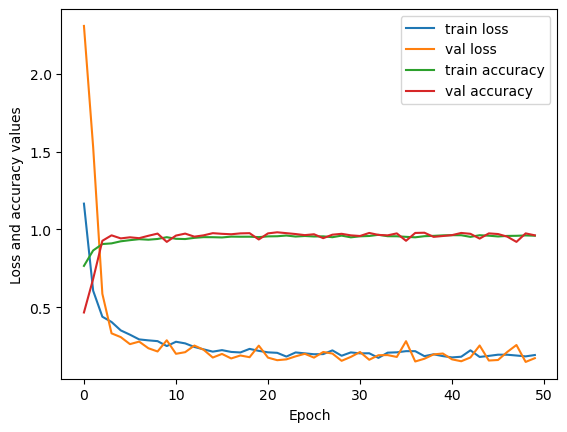

In [22]:
xc         = range(num_epochs)
plt.plot(xc, seqModel.history['loss'], label='train loss')
plt.plot(xc, seqModel.history['val_loss'], label='val loss')
plt.plot(xc, seqModel.history['accuracy'], label='train accuracy')
plt.plot(xc, seqModel.history['val_accuracy'], label='val accuracy')
plt.xlabel('Epoch')
plt.ylabel('Loss and accuracy values')
plt.legend()

In [23]:
with custom_object_scope({'SeqSelfAttention': SeqSelfAttention}):
    load_model = keras.models.load_model('tuned_sliced_th_calc_2-12_retrain.h5')

In [24]:
load_model.evaluate(X_test, y_test)
y_pred_prob = load_model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
confusion = confusion_matrix(y_test, y_pred)
recall = recall_score(y_test, y_pred, average=None)
f1 = f1_score(y_test, y_pred, average=None)
precision = precision_score(y_test, y_pred, average=None)
print('Confusion matrix', confusion)
print('Recall score:', recall)
print('F1 score:', f1)
print('Precision score:', precision)

23/23 [==============================] - 1s 37ms/step
Confusion matrix [[142   0   0   0   0   0   0   0   0]
 [  0 171   0   0   0   0   0   0   0]
 [  0   0 161   0   0   0   0   0   0]
 [  0   0   0 116   0   0   0   0   0]
 [  0   0   0   1  61   3   0   0   0]
 [  0   0   0   0   1  38   0   0   0]
 [  0   0   0   0   0   4   6   1   0]
 [  0   0   0   0   0   0   1   4   0]
 [  0   0   0   0   0   0   0   3   0]]
Recall score: [1.         1.         1.         1.         0.93846154 0.97435897
 0.54545455 0.8        0.        ]
F1 score: [1.         1.         1.         0.99570815 0.96062992 0.9047619
 0.66666667 0.61538462 0.        ]
Precision score: [1.         1.         1.         0.99145299 0.98387097 0.84444444
 0.85714286 0.5        0.        ]


/Users/dimitrygrebenyuk/miniforge3/envs/keras/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Confusion matrix, without normalization
[[142   0   0   0   0   0   0   0   0]
 [  0 171   0   0   0   0   0   0   0]
 [  0   0 161   0   0   0   0   0   0]
 [  0   0   0 116   0   0   0   0   0]
 [  0   0   0   1  61   3   0   0   0]
 [  0   0   0   0   1  38   0   0   0]
 [  0   0   0   0   0   4   6   1   0]
 [  0   0   0   0   0   0   1   4   0]
 [  0   0   0   0   0   0   0   3   0]]


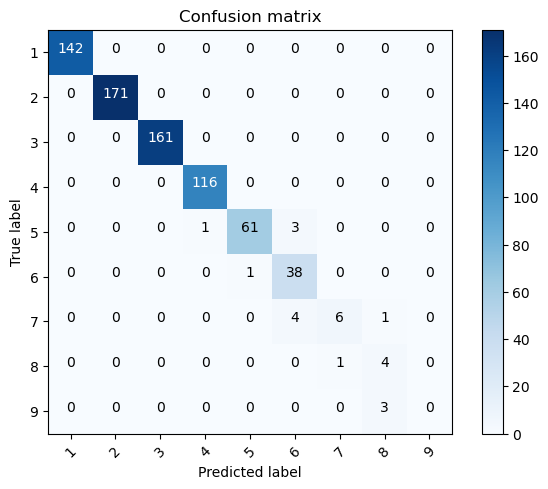

In [25]:
import matplotlib.pyplot as plt

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)
    
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Plot the confusion matrix
plot_confusion_matrix(confusion, classes = np.unique(y_test), title='Confusion matrix', normalize=False)
plt.show()

The implemented attention mechanism can be a key to interpretability of the model, making it possible to assess from the trained model attention weights, which areas of the PDF are considered the most important by the model. For that, we need to load the trianed model, extract the attention layer and then plot the average attention weights together with PDFs which we used as an input for the model training to visualize the important regions in the data.

In [143]:
# Extraction of attention weights from the model
from keras.models import Model

with custom_object_scope({'SeqSelfAttention': SeqSelfAttention}):
    loaded_model = keras.models.load_model('tuned_sliced_th_calc_2-12_retrain.h5')
attention_layer = [layer for layer in loaded_model.layers if 'SeqSelfAttention' in str(layer)][0]
model_with_attentions = Model(inputs=loaded_model.input, 
                              outputs=[loaded_model.output, attention_layer.output])

total_samples = X_test.shape[0]
batch_size = 32 # keras default
all_attention_weights = []
for i in range(0, total_samples, batch_size):
    batch_input = X_test[i:i+batch_size]
    _, attention_weights = model_with_attentions.predict(batch_input, verbose='none')
    all_attention_weights.append(attention_weights)
all_attention_weights = np.concatenate(all_attention_weights, axis=0)
average_attention_weights = np.mean(all_attention_weights, axis=0)
summed_attention_weights = np.sum(average_attention_weights, axis=0)

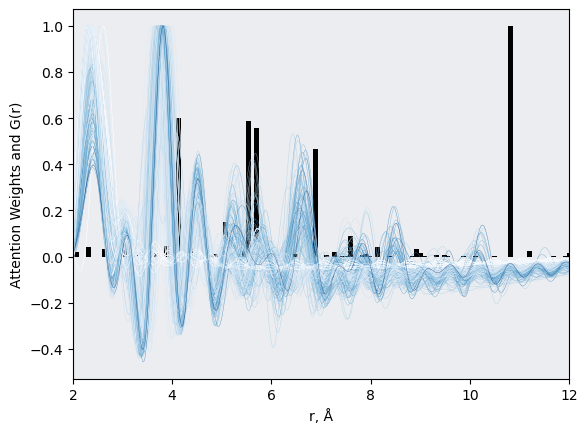

In [168]:
# Plotting of attention weights together with the first 300 PDFs of the dataset
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.cm import get_cmap

min_val = np.min(labels)
max_val = np.max(labels)
normalized_labels = (labels - min_val) / (max_val - min_val)
colormap = get_cmap('Blues')


fig, ax = plt.subplots()
for i in range(1,300):
    color = colormap(normalized_labels[i])
    plt.plot(np.arange(len(data_points[i,:]))/100+2, data_points[i,:]/data_points[i,:].max(), 
             alpha=0.7, linewidth=0.3, color=color)
ax.bar(np.linspace(2, 12, 128), summed_attention_weights/summed_attention_weights.max(), width=0.1, color='black')
ax.set_facecolor('#ebedf0')
plt.xlabel('r, Å')
plt.ylabel('Attention Weights and G(r)')
ax.set_xlim(2,12)
plt.show()

7


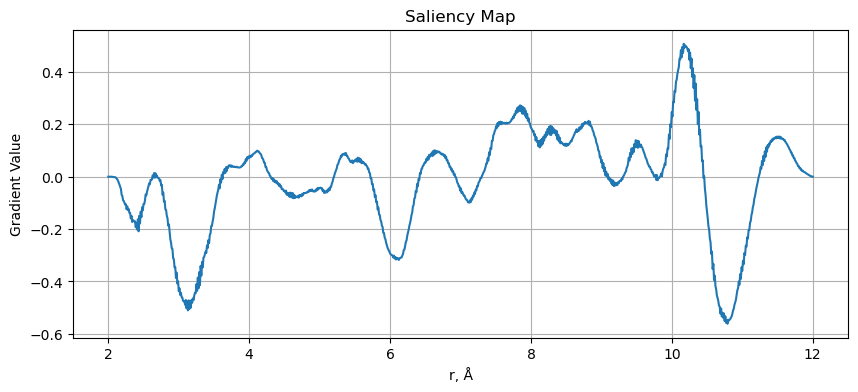

In [196]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Load pre-trained model
with custom_object_scope({'SeqSelfAttention': SeqSelfAttention}):
    model = keras.models.load_model('tuned_sliced_th_calc_2-12_retrain.h5')

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

sample_index = 1  
sample_label = y_train[sample_index]
some_input = tf.convert_to_tensor(X_train[sample_index].reshape(1, 1000, 1), dtype=tf.float32)  # Adjust shape according to your input

with tf.GradientTape() as tape:
    tape.watch(some_input)
    prediction = model(some_input)
    loss = prediction[0][sample_label]

grad_values = tape.gradient(loss, some_input)
grad_numpy = grad_values.numpy().reshape(1000)
print(y_train[sample_index])
angstrom_range = 2 + np.linspace(0, 1000, 1000) / 100

# Plot
plt.figure(figsize=(10, 4))
plt.plot(angstrom_range, grad_numpy)
plt.title('Saliency Map')
plt.xlabel('r, Å')
plt.ylabel('Gradient Value')
plt.grid(True)
plt.show()

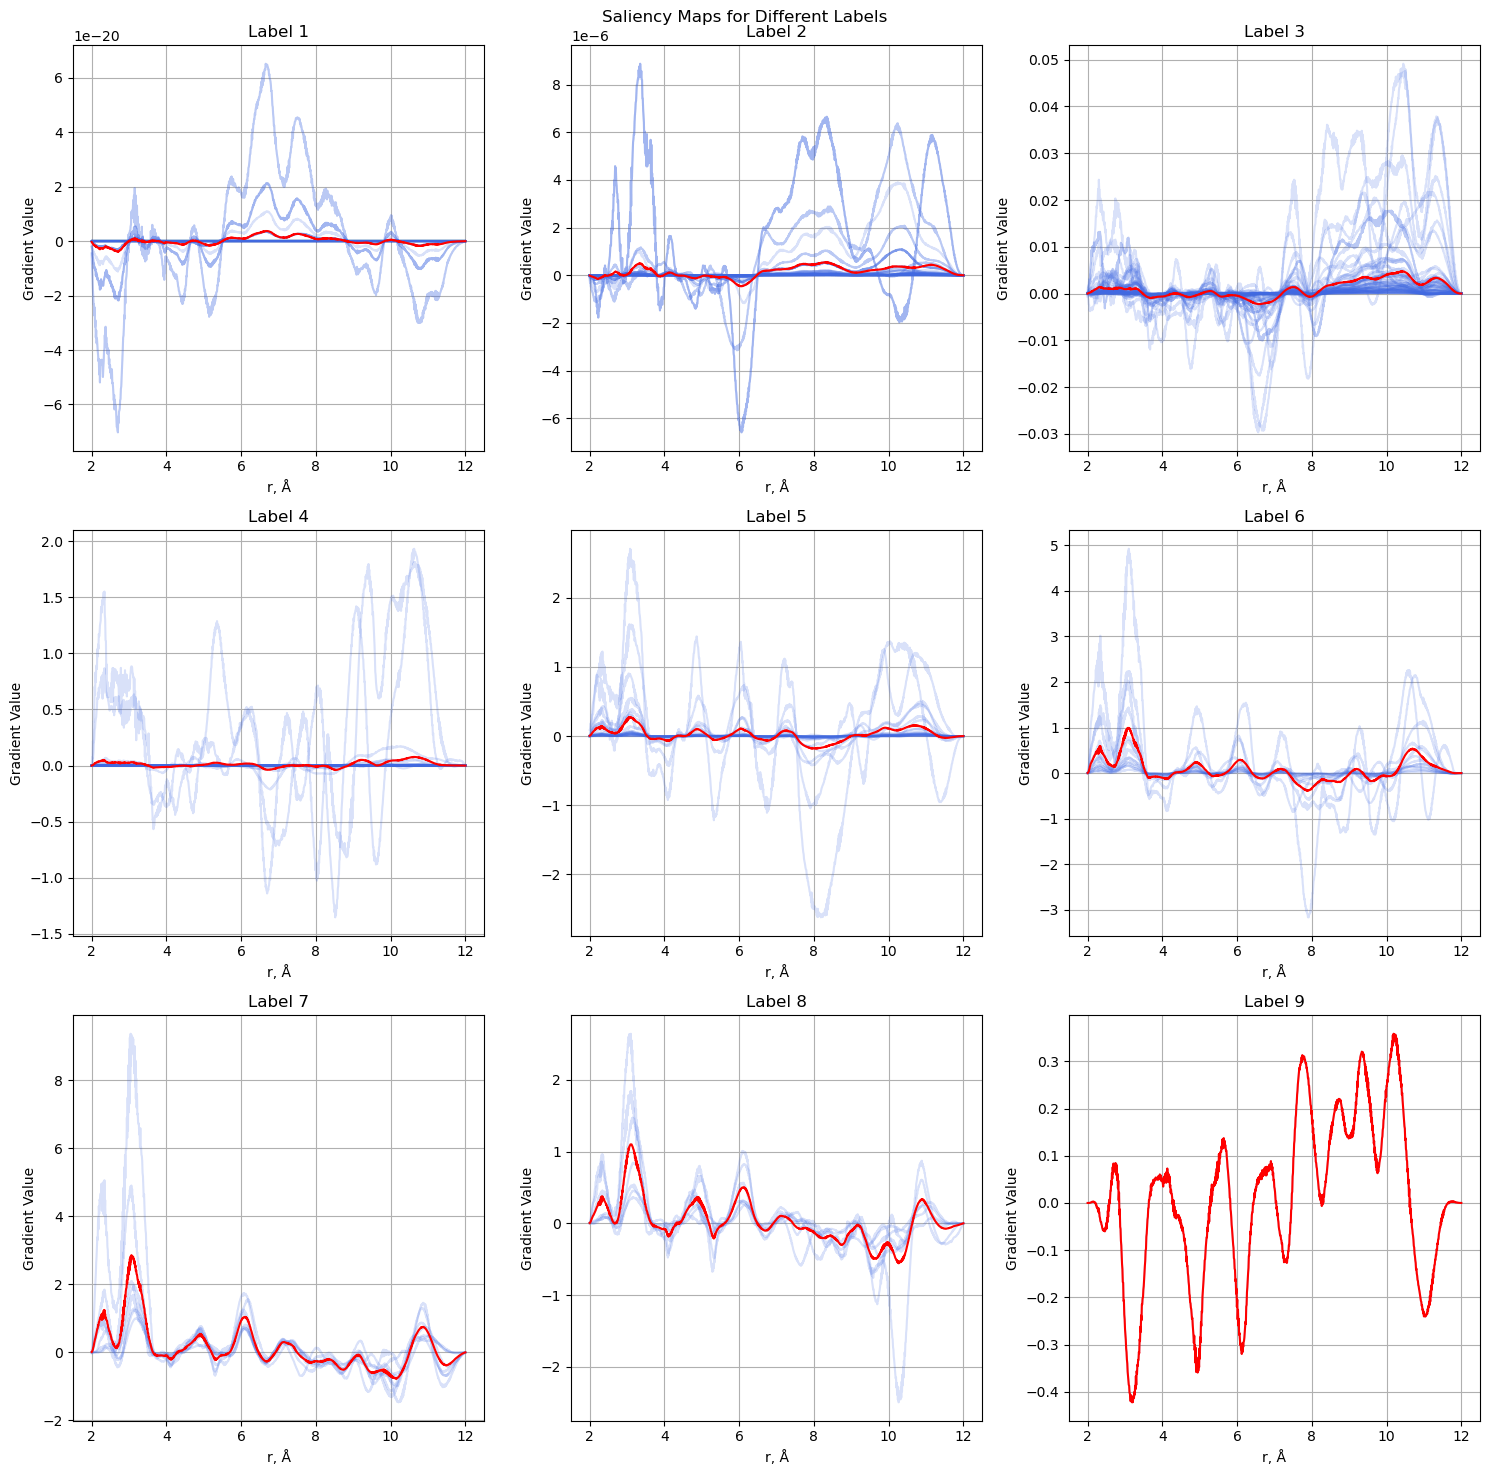

In [208]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

sample_size = 300
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
fig.suptitle('Saliency Maps for Different Labels')

# Loop through the unique labels (from 1 to 9)
for label in range(1, 10):
    ax = axes[(label - 1) // 3, (label - 1) % 3]
    gradients = []
    
    # Loop through first `sample_size` samples to check for this label
    for idx in range(min(sample_size, len(y_train))):
        if y_train[idx] == label:
            sample_input = tf.convert_to_tensor(X_train[idx].reshape(1, 1000, 1), dtype=tf.float32)
            
            with tf.GradientTape() as tape:
                tape.watch(sample_input)
                prediction = model(sample_input)
                loss = prediction[0][label - 1]  # Adjust for 0-based index
            
            grad_values = tape.gradient(loss, sample_input)
            grad_numpy = grad_values.numpy().reshape(1000)
            gradients.append(grad_numpy)
            
            angstrom_range = 2 + np.linspace(0, 1000, 1000) / 100
            ax.plot(angstrom_range, grad_numpy, alpha=0.2, color='royalblue')
    
    # Plot the average line if we have any gradients for this label
    if gradients:
        mean_gradient = np.mean(gradients, axis=0)
        ax.plot(angstrom_range, mean_gradient, color='red')
    
    ax.set_title(f'Label {label}')
    ax.set_xlabel('r, Å')
    ax.set_ylabel('Gradient Value')
    ax.grid(True)

plt.tight_layout()
plt.savefig('saliency_maps.png', dpi=400)
plt.show()